In [1]:
print("Hello, World!")

Hello, World!


In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt

files = ["Bond_045","Bond_060","Bond_075","Bond_090","Bond_105","Bond_120","Bond_135"]

df1 = pd.read_pickle("Data_results/Bond_045/Result_dataframe.pkl")
df2 = pd.read_pickle("Data_results/Bond_060/Result_dataframe.pkl")
df3 = pd.read_pickle("Data_results/Bond_075/Result_dataframe.pkl") 
df4 = pd.read_pickle("Data_results/Bond_090/Result_dataframe.pkl")
df5 = pd.read_pickle("Data_results/Bond_105/Result_dataframe.pkl")
df6 = pd.read_pickle("Data_results/Bond_120/Result_dataframe.pkl")
df7 = pd.read_pickle("Data_results/Bond_135/Result_dataframe.pkl")

df_QPU = pd.concat([df1, df2, df3, df4, df5, df6, df7], ignore_index=True)
df_QPU.head()


,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.45,"{'x': [-0.0033706870346540824, 0.0451681604390...",-0.729711,976.281680,1.175949,-1.905661,"[-1.9056607601812363, -1.1087295761364029, -1....","[-0.0033706870346540824, 0.045168160439022886,..."
1,0.60,"{'x': [0.15019989790151939, -0.036218425787422...",-0.858650,286.460181,0.881962,-1.740612,"[-1.6922736976601185, -1.0871196283339861, -1....","[0.15019989790151939, -0.0362184257874225, -0...."
2,0.75,"{'x': [0.05622898238231749, 0.0619351373444218...",-0.908009,1897.637656,0.705570,-1.613579,0,0
3,0.90,"{'x': [0.10049179736462063, 0.0528177715341626...",-0.954234,726.472458,0.587975,-1.542208,"[-1.538616650592773, -1.112869681623636, -1.17...","[0.10049179736462063, 0.05281777153416269, -0...."
4,1.05,"{'x': [-0.05268460867377192, -0.00965118800572...",-0.963867,1389.771611,0.503978,-1.467846,"[-1.4404440826618614, -1.1348218217114512, -1....","[-0.05268460867377192, -0.009651188005724873, ..."


In [2]:
df_Aer = pd.read_pickle("Data_results/Aer_Simulator_Results/Aer_Results_2.pkl")
df_Aer.head()
df_Svec = pd.read_pickle("Data_results/Statevector_Results/Statevector_Results.pkl")
df_Svec.head()

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [-0.019763072203464422, 0.00658970185559...",-0.600759,0.267545,1.763924,-2.364683,"[-2.340573527555158, -1.1155722069641365, -1.1...","[-0.019763072203464422, 0.0065897018555995945,..."
1,0.35,"{'x': [0.002005024661644707, 0.005846551962562...",-0.789182,0.228899,1.511935,-2.301117,"[-2.279420902628475, -1.1453831826424905, -1.1...","[0.002005024661644707, 0.0058465519625622965, ..."
2,0.40,"{'x': [-0.02059801123137401, 0.005641471995903...",-0.913357,0.166206,1.322943,-2.236300,"[-2.2184181081598573, -1.1713488089183308, -1....","[-0.02059801123137401, 0.005641471995903158, -..."
3,0.45,"{'x': [-0.01594725525986933, 0.006576564931376...",-0.997445,0.220123,1.175949,-2.173395,"[-2.158462301041319, -1.1928303594183982, -1.2...","[-0.01594725525986933, 0.0065765649313765774, ..."
4,0.50,"{'x': [-0.016419325527923436, 0.00578139633301...",-1.054337,0.190982,1.058354,-2.112692,"[-2.100007320448122, -1.2096042793649495, -1.2...","[-0.016419325527923436, 0.0057813963330108145,..."


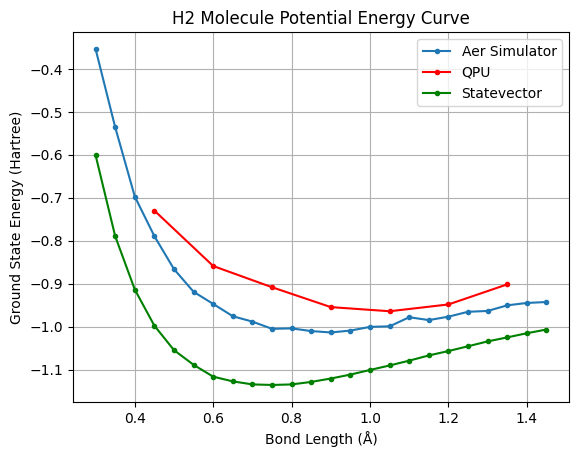

In [4]:

plt.plot(df_Aer["Bond Length"], df_Aer["Ground State Energy (Hartree)"], marker='.', label='Aer Simulator')
plt.plot(df_QPU["Bond Length"], df_QPU["Ground State Energy (Hartree)"], marker='.', color='red', label='QPU')
plt.plot(df_Svec["Bond Length"], df_Svec["Ground State Energy (Hartree)"], marker='.', color='green', label='Statevector')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)") 
plt.grid(True)
plt.title("H2 Molecule Potential Energy Curve")
plt.legend()
plt.show()

In [5]:
df_Aer["Bond Length"] = df_Aer["Bond Length"].round(2)
df_Svec["Bond Length"] = df_Svec["Bond Length"].round(2)
df_QPU["Bond Length"] = df_QPU["Bond Length"].round(2)

In [6]:
bond_points = df_QPU["Bond Length"]

df_Aer_small = df_Aer[df_Aer["Bond Length"].isin(bond_points)]
df_Svec_small = df_Svec[df_Svec["Bond Length"].isin(bond_points)]

In [7]:
df_combined = pd.merge(df_QPU, df_Aer_small, on="Bond Length", suffixes=('_QPU', '_Aer'))
df_combined = pd.merge(df_combined, df_Svec_small, on="Bond Length", suffixes=('','_Svec'))
df_combined.head()

,Bond Length,Results_QPU,Ground State Energy (Hartree)_QPU,Time (s)_QPU,Nuclear Repulsion Energy (Hartree)_QPU,Electronic Energies (Hartree)_QPU,Convergence History_QPU,optimal_parameters_list_QPU,Results_Aer,Ground State Energy (Hartree)_Aer,...,Electronic Energies (Hartree)_Aer,Convergence History_Aer,optimal_parameters_list_Aer,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.45,"{'x': [-0.0033706870346540824, 0.0451681604390...",-0.729711,976.281680,1.175949,-1.905661,"[-1.9056607601812363, -1.1087295761364029, -1....","[-0.0033706870346540824, 0.045168160439022886,...","{'x': [0.09002597984269597, 0.0439822450891662...",-0.789255,...,-1.965205,"[-1.9618686009992872, -1.0882514290141028, -1....","[0.09002597984269597, 0.043982245089166275, -0...","{'x': [-0.01594725525986933, 0.006576564931376...",-0.997445,0.190412,1.175949,-2.173395,"[-2.158462301041319, -1.1928303594183982, -1.2...","[-0.01594725525986933, 0.0065765649313765774, ..."
1,0.60,"{'x': [0.15019989790151939, -0.036218425787422...",-0.858650,286.460181,0.881962,-1.740612,"[-1.6922736976601185, -1.0871196283339861, -1....","[0.15019989790151939, -0.0362184257874225, -0....","{'x': [0.025222257972730026, 0.004318705928873...",-0.946851,...,-1.828813,"[-1.8194324409574376, -1.1517580933783174, -1....","[0.025222257972730026, 0.004318705928873269, -...","{'x': [-0.005676903382171844, -0.0091916187861...",-1.116049,0.177734,0.881962,-1.998011,"[-1.9883462678695967, -1.2294621437209592, -1....","[-0.005676903382171844, -0.009191618786169416,..."
2,0.75,"{'x': [0.05622898238231749, 0.0619351373444218...",-0.908009,1897.637656,0.705570,-1.613579,0,0,"{'x': [0.06094690279475859, -0.058352602161209...",-1.004726,...,-1.710296,"[-1.7003469855677, -1.1642390732025416, -1.221...","[0.06094690279475859, -0.058352602161209854, -...","{'x': [0.0044290821008509465, 0.00997089209238...",-1.135370,0.351308,0.705570,-1.840939,"[-1.8352483392679613, -1.2307562334968907, -1....","[0.0044290821008509465, 0.009970892092380855, ..."
3,0.90,"{'x': [0.10049179736462063, 0.0528177715341626...",-0.954234,726.472458,0.587975,-1.542208,"[-1.538616650592773, -1.112869681623636, -1.17...","[0.10049179736462063, 0.05281777153416269, -0....","{'x': [-0.015712921218211776, 0.05923414662417...",-1.013212,...,-1.601187,"[-1.583719970251413, -1.1455486002218604, -1.1...","[-0.015712921218211776, 0.05923414662417866, -...","{'x': [-0.002182320428635136, -0.0091024659921...",-1.120386,0.426590,0.587975,-1.708361,"[-1.7001868714609452, -1.2100592517336004, -1....","[-0.002182320428635136, -0.009102465992133936,..."
4,1.05,"{'x': [-0.05268460867377192, -0.00965118800572...",-0.963867,1389.771611,0.503978,-1.467846,"[-1.4404440826618614, -1.1348218217114512, -1....","[-0.05268460867377192, -0.009651188005724873, ...","{'x': [0.041279564745483964, -0.06453210947936...",-0.998906,...,-1.502884,"[-1.4852667273697044, -1.122189703966129, -1.1...","[0.041279564745483964, -0.06453210947936355, -...","{'x': [0.013579411534498787, -0.00132077074226...",-1.089969,0.199597,0.503978,-1.593948,"[-1.5816989599760347, -1.1785428718088649, -1....","[0.013579411534498787, -0.0013207707422697324,..."


In [8]:
df_results = df_combined[["Bond Length", "Ground State Energy (Hartree)_QPU", "Ground State Energy (Hartree)_Aer", "Ground State Energy (Hartree)"]]

In [9]:
df_results.head()

,Bond Length,Ground State Energy (Hartree)_QPU,Ground State Energy (Hartree)_Aer,Ground State Energy (Hartree)
0,0.45,-0.729711,-0.789255,-0.997445
1,0.60,-0.858650,-0.946851,-1.116049
2,0.75,-0.908009,-1.004726,-1.135370
3,0.90,-0.954234,-1.013212,-1.120386
4,1.05,-0.963867,-0.998906,-1.089969


In [10]:
df_results.rename(columns={"Ground State Energy (Hartree)_QPU": "GS Energy QPU", "Ground State Energy (Hartree)_Aer": "GS Energy Aer", "Ground State Energy (Hartree)": "GS Energy Svec"}, inplace=True)

In [11]:
df_results.head(7)

,Bond Length,GS Energy QPU,GS Energy Aer,GS Energy Svec
0,0.45,-0.729711,-0.789255,-0.997445
1,0.60,-0.858650,-0.946851,-1.116049
2,0.75,-0.908009,-1.004726,-1.135370
3,0.90,-0.954234,-1.013212,-1.120386
4,1.05,-0.963867,-0.998906,-1.089969
5,1.20,-0.948036,-0.976473,-1.056434
6,1.35,-0.901325,-0.950083,-1.024689


In [12]:
df_results.to_pickle("Data_results/Combined_Results.pkl")

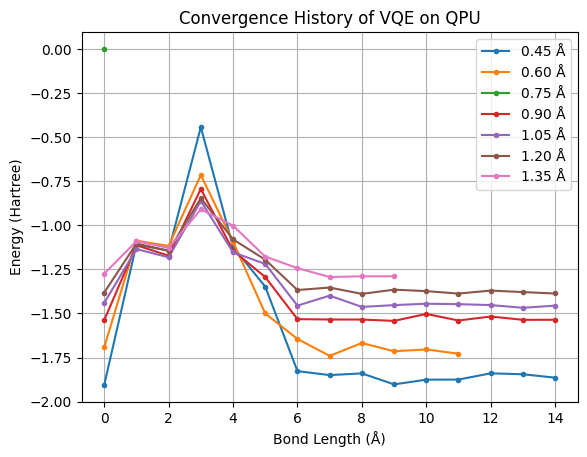

In [18]:
for history in df_combined["Convergence History_QPU"]:
    plt.plot(history, marker='.')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("Convergence History of VQE on QPU")
plt.grid(True)
plt.legend([f"{r:.2f} Å" for r in df_combined["Bond Length"]], loc='upper right')
plt.show()

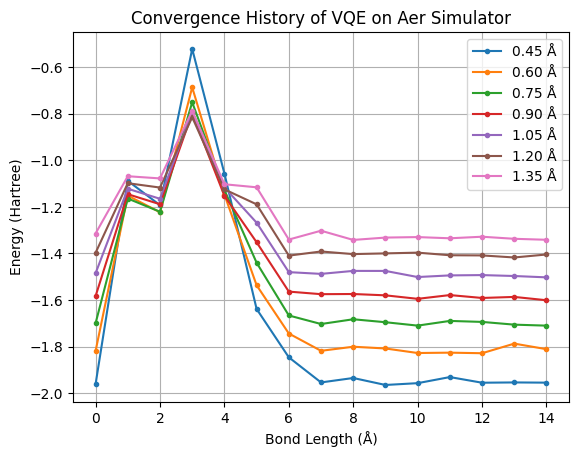

In [19]:
for history in df_combined["Convergence History_Aer"]:
    plt.plot(history, marker='.')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("Convergence History of VQE on Aer Simulator")
plt.grid(True)
plt.legend([f"{r:.2f} Å" for r in df_combined["Bond Length"]], loc='upper right')
plt.show()


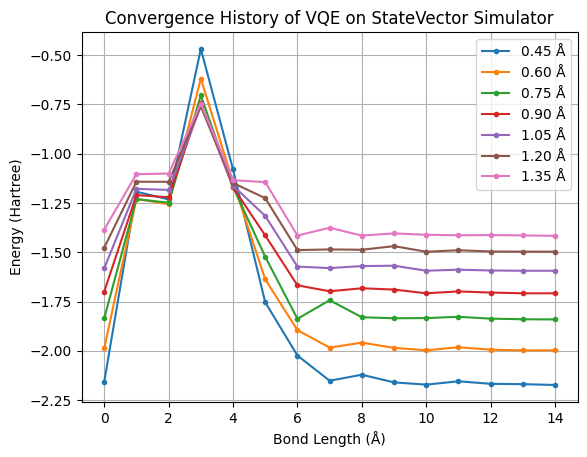

In [20]:
for history in df_combined["Convergence History"]:
    plt.plot(history, marker='.')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("Convergence History of VQE on StateVector Simulator")
plt.grid(True)
plt.legend([f"{r:.2f} Å" for r in df_combined["Bond Length"]], loc='upper right')
plt.show()

In [15]:
df_results.head()

,Bond Length,GS Energy QPU,GS Energy Aer,GS Energy Svec
0,0.45,-0.729711,-0.789255,-0.997445
1,0.60,-0.858650,-0.946851,-1.116049
2,0.75,-0.908009,-1.004726,-1.135370
3,0.90,-0.954234,-1.013212,-1.120386
4,1.05,-0.963867,-0.998906,-1.089969


In [ ]:
df_Aer.head()

KeyError: ('Bond Length', 'Ground State Energy (Hartree)')